In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("medical_cost.csv")

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.drop("Id",axis=1,inplace=True)

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [8]:
df['charges'].nunique()

1337

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


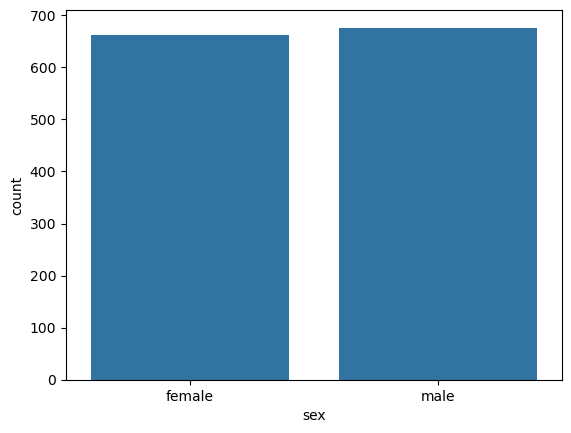

In [10]:
sns.countplot(data=df, x = "sex")
plt.show()

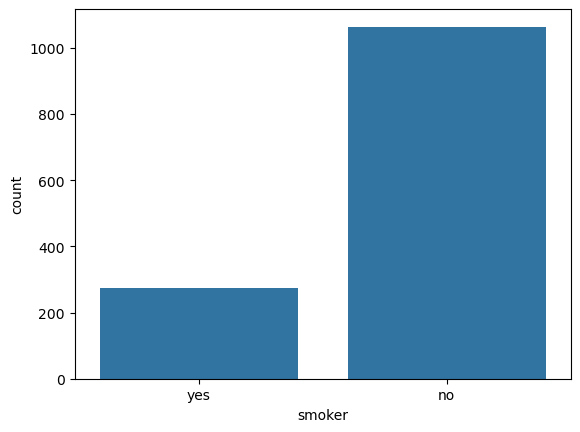

In [11]:
sns.countplot(data=df, x = "smoker")
plt.show()

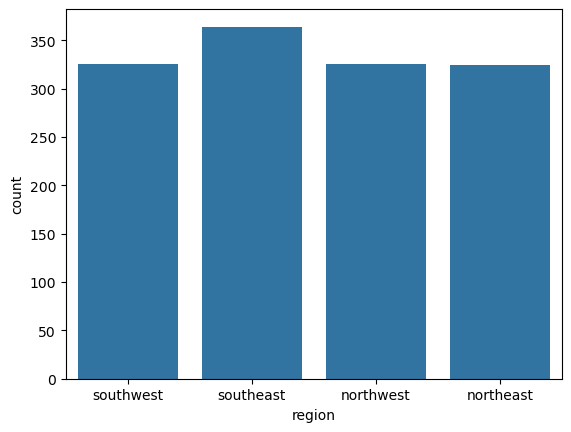

In [12]:
sns.countplot(data=df, x = "region")
plt.show()

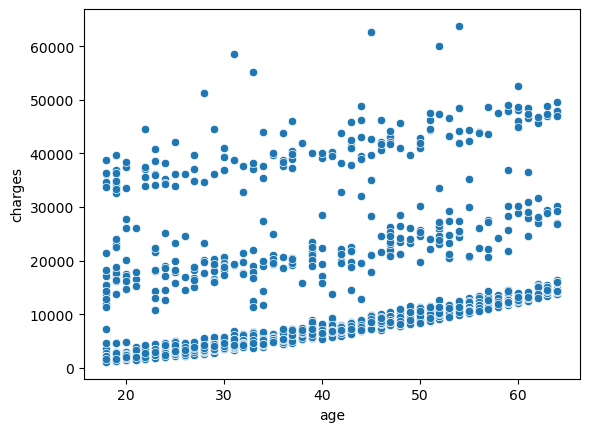

In [13]:
sns.scatterplot(x=df['age'], y =df['charges'])
plt.show()

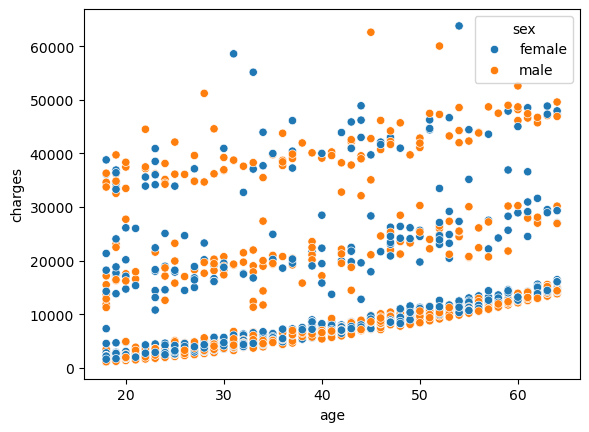

In [14]:
sns.scatterplot(x=df['age'], y =df['charges'], hue=df['sex'])
plt.show()

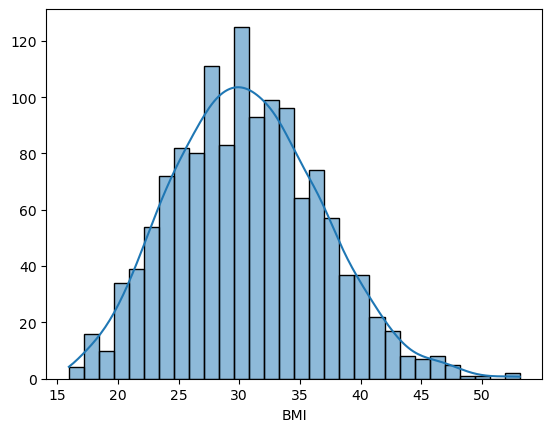

In [15]:
sns.histplot(x=df['bmi'], kde=True, bins=30)
plt.xlabel("BMI")
plt.ylabel("")
plt.show()

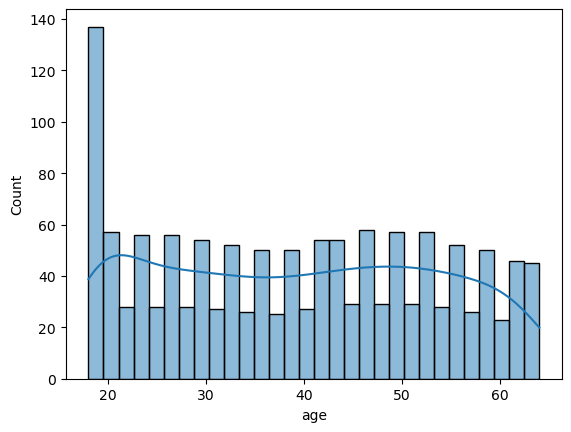

In [16]:
sns.histplot(x=df['age'], kde=True, bins=30)
plt.show()

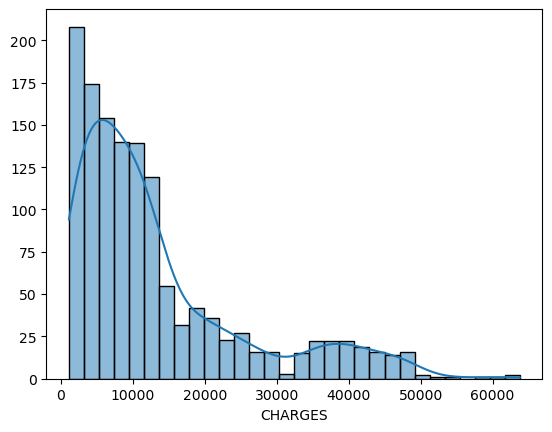

In [17]:
sns.histplot(x=df['charges'], kde=True, bins=30)
plt.xlabel("CHARGES")
plt.ylabel("")
plt.show()

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df['sex'] = df['sex'].map({"female":1,"male":0})
df['smoker'] = df['smoker'].map({"no":0,"yes":1})

In [20]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [21]:
X = df.drop("charges", axis=1)
y = df['charges']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [25]:
categorical_cols = ["region"]

preprocessor = ColumnTransformer(transformers=[
    ("OneHot",OneHotEncoder(drop="first",handle_unknown="ignore"),categorical_cols)
],remainder="passthrough")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

cols_name = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(data=X_train, columns=cols_name)
X_test = pd.DataFrame(data=X_test, columns=cols_name)

In [54]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [56]:
model = LGBMRegressor()
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374.181390


LGBMRegressor()

In [62]:
y_pred = model.predict(X_test)
print("Score: ",r2_score(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

Score:  0.871843376594573
RMSE:  18458085.613847945


In [64]:
param_grid = {
    "num_leaves" : [31, 50, 70],
    "max_depth" : [-1, 5, 10],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 300, 1000],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "reg_alpha" : [0, 0.5, 1.0],
    "reg_lambda" : [0, 0.5, 1.0]
}

In [68]:
import warnings
warnings.filterwarnings("ignore")

In [70]:
from sklearn.model_selection import RandomizedSearchCV

In [84]:
random = RandomizedSearchCV(estimator=LGBMRegressor(),
                            param_distributions=param_grid,
                            cv=5,
                            n_jobs=-1,
                            verbose=0,
                            scoring="neg_root_mean_squared_error")

In [86]:
random.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374.181390
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

RandomizedSearchCV(cv=5, estimator=LGBMRegressor(), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 10],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 300, 1000],
                                        'num_leaves': [31, 50, 70],
                                        'reg_alpha': [0, 0.5, 1.0],
                                        'reg_lambda': [0, 0.5, 1.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_root_mean_squared_error')

In [87]:
random.best_params_

{'subsample': 1.0,
 'reg_lambda': 0,
 'reg_alpha': 0.5,
 'num_leaves': 70,
 'n_estimators': 1000,
 'min_child_samples': 30,
 'max_depth': 5,
 'learning_rate': 0.01,
 'colsample_bytree': 0.6}

In [88]:
y_pred = random.predict(X_test)
print("Score: ",r2_score(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

Score:  0.8978018682239357
RMSE:  3836.5801743474763


In [92]:
from scipy.stats import boxcox

In [94]:
y_train_transformed, lambda_y = boxcox(y_train)

In [96]:
model = LGBMRegressor()
model.fit(X_train,y_train_transformed)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 12.319019


LGBMRegressor()

In [98]:
y_pred_transformed = model.predict(X_test)

In [100]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [104]:
y_pred = inverse_boxcox(y_pred_transformed,lambda_y)

In [106]:
print("Score: ",r2_score(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

Score:  0.8925898035961266
RMSE:  3933.195695471598
